# Position embeddings

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# highres plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# export GPT2 model and extract position embedding matrix

In [3]:
# load the model
from transformers import GPT2Model
gpt2 = GPT2Model.from_pretrained('gpt2')
gpt2

/Users/shre/courses/llm_deep_dive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [4]:
# position embeddings
positions = gpt2.wpe.weight.detach().numpy()

# check the size of the matrix
positions.shape

(1024, 768)

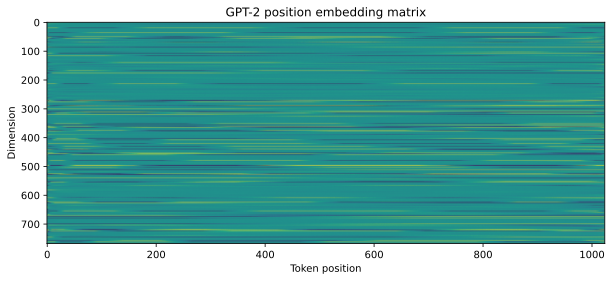

In [5]:
# visualize the matrix
plt.figure(figsize=(10,4))
plt.imshow(positions.T, aspect='auto', vmin=-.2, vmax=.2)
plt.gca().set(xlabel="Token position",
              ylabel="Dimension",
              title="GPT-2 position embedding matrix")
plt.show()

In [7]:
positions.shape[1]

768

# visualize some position vectors

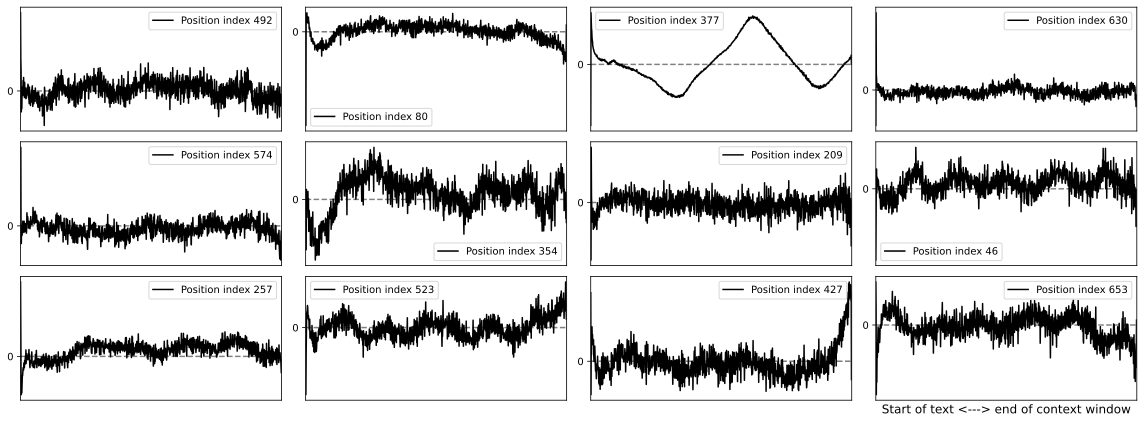

In [8]:
_, axs = plt.subplots(3, 4, figsize=(16,6))

# pick random vectors
for a in axs.flatten():
    # a random position embedding vector
    randidx = np.random.randint(positions.shape[1])

    # and plot it
    a.plot(positions[:, randidx], 'k', label=f"Position index {randidx}")
    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(xticks=[], yticks=[0], xlim=[0, positions.shape[0]])
    a.legend(fontsize=10)

# x-axis label on one plot
a.set_xlabel('Start of text <---> end of context window', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
np.linalg.norm(positions, axis=1, keepdims=True)

array([[9.875602 ],
       [5.1921554],
       [4.5852723],
       ...,
       [3.8822126],
       [3.8578684],
       [0.1179292]], shape=(1024, 1), dtype=float32)

In [11]:
ax0_ = np.linalg.norm(positions,axis=0,keepdims=True)
ax0_.shape

(1, 768)

# similarities across vectors

In [12]:
# cosine similarities for "time series" (token index)
Pnorm1 = positions / np.linalg.norm(positions, axis=1, keepdims=True)
cossim_tokens = Pnorm1 @ Pnorm1.T

# cosine similarities across embedding dimensions
Pnorm0 = positions / np.linalg.norm(positions, axis=0, keepdims=True)
cossim_embeds = Pnorm0.T @ Pnorm0

print(f"Shape of tokens cosine similarities: {cossim_tokens.shape}")
print(f"Shape of embeds cosine similarities: {cossim_embeds.shape}")

Shape of tokens cosine similarities: (1024, 1024)
Shape of embeds cosine similarities: (768, 768)


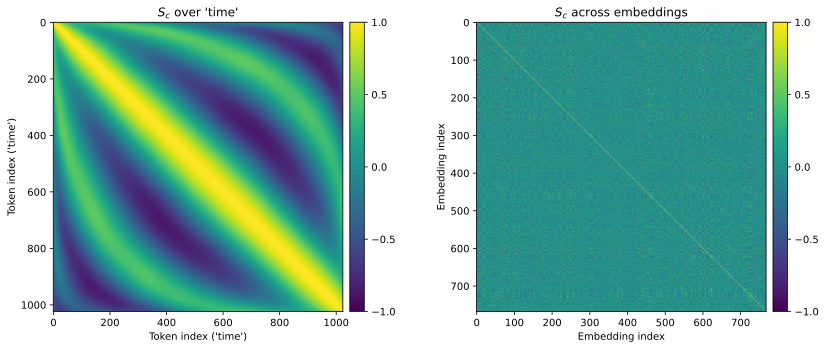

In [13]:
# draw the images
fig, axs = plt.subplots(1, 2, figsize=(12,5))

h = axs[0].imshow(cossim_tokens, vmin=-1, vmax=1)
axs[0].set(xlabel="Token index ('time')",
           ylabel="Token index ('time')",
           title="$S_c$ over 'time'")
ch = fig.colorbar(h, ax=axs[0], pad=.02, fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

h = axs[1].imshow(cossim_embeds, vmin=-1, vmax=1)
axs[1].set(xlabel="Embedding index",
           ylabel="Embedding index",
           title="$S_c$ across embeddings")
ch = fig.colorbar(h, ax=axs[1], pad=.02, fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

plt.tight_layout()
plt.show()

# Sinusoidal embeddings as defines in "Attention" paper

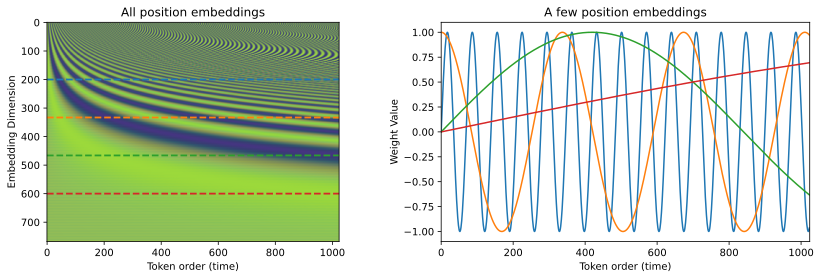

In [14]:
positions_formula = np.zeros_like(gpt2.wpe.weight.data)
d = positions_formula.shape[1]

# token positions ("time")
th = np.arange(positions_formula.shape[0])

# create the vectors
for i in range(0, positions_formula.shape[1], 2):
    # denomiantor scaling factor
    denom = 10000 ** (2*i//2 / d)

    # define the embeddings
    positions_formula[:, i]   = np.sin(th / denom)
    positions_formula[:, i+1] = np.cos(th / denom)

# and visualize
_, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].imshow(positions_formula.T, vmin=-1, vmax=1)
axs[0].set(ylabel="Embedding Dimension",
           xlabel="Token order (time)",
           title="All position embeddings")

pos2show = np.linspace(200, 600, 4, dtype=int)
h = axs[1].plot(positions_formula[:, pos2show])
axs[1].set(ylabel="Weight Value",
           xlabel="Token order (time)",
           xlim=[0,len(th)],
           title="A few position embeddings")

for i, p in enumerate(pos2show):
    axs[0].axhline(p, linestyle='--', color=h[i].get_color(), linewidth=1.8)

plt.tight_layout()
plt.show()

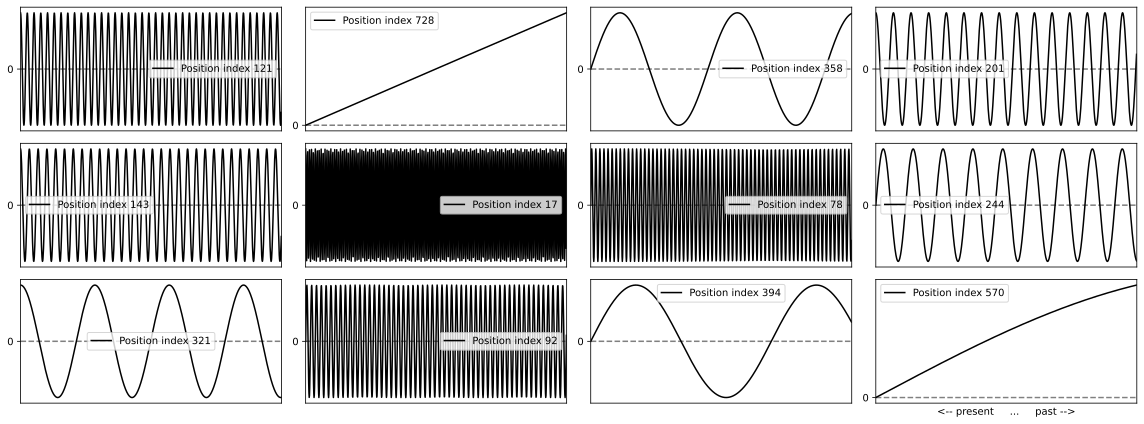

In [15]:
# sample plot as earlier with the learned embeddings

_,axs = plt.subplots(3,4,figsize=(16,6))

# pick random vectors
for a in axs.flatten():

    # a random position embedding vector
    randidx = np.random.randint(positions.shape[1])

    # and plot it
    a.plot(positions_formula[:,randidx],'k',label=f'Position index {randidx}')
    a.axhline(0,linestyle='--',color='gray',zorder=-3)

    a.set(xticks=[],yticks=[0],xlim=[0,positions.shape[0]])
    a.legend(fontsize=10)


# x-axis label on one plot
a.set(xlabel='<-- present     ...     past -->')
plt.tight_layout()
plt.show()